NAIVE BAYES

The modeling objective: 
To build and test a Naive Bayes model that uses banking data to predict whether a customer will churn. 

Target variable: 
Same as the Feature Engineering, the target variable is Exited where -- 0 = did not leave, 1 = did leave. For each customer, our model will predict whether they should have a 0 or a 1 in the Exited column.

So, here we are using the GaussianNB classifier 

why GaussianNB -- as it assumes that all of your variables are continuous and that they have a Gaussian i.e., normal distribution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
churn_df = pd.read_csv('churn_df.csv')
churn_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Loyalty,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,0.047619,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.024390,0,1
2,502,42,8,159660.80,3,1,0,113931.57,1,0.190476,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0.025641,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0.046512,0,1


In [3]:
#check the  class balance of the target variable
churn_df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

Unlike feature engineering -- we cannot alter the class balance of our target variable 

Also, the class is split as 80 - 20 ----- an unbalanced dataset.

Naive Bayes formula depends on class priors _(P(c))_ to make predictions. Because of this, performing class balancing (e.g., upsampling or downsampling) would change those terms. 

In [4]:
# dropping the dependent variables
churn_df = churn_df.drop(['Tenure', 'Age'], axis=1)
churn_df.head()

,CreditScore,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Loyalty,Geography_Germany,Geography_Spain
0,619,0.00,1,1,1,101348.88,1,0.047619,0,0
1,608,83807.86,1,0,1,112542.58,0,0.024390,0,1
2,502,159660.80,3,1,0,113931.57,1,0.190476,0,0
3,699,0.00,2,0,0,93826.63,0,0.025641,0,0
4,850,125510.82,1,1,1,79084.10,0,0.046512,0,1


Spliting the data: 

We must split the data into features and target variable, and into training data and test data. We do this using the train_test_split() function. 

We'll put 25% of the data into our test set, and use the remaining 75% to train the model.


In [5]:
# y (target) variable
y = churn_df['Exited']

# X (predictor) variables
X = churn_df.copy()
X = X.drop('Exited', axis=1)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, \
                                                    stratify=y, random_state=42)

## Modeling

1. Unscaled data -- starting with basics with LINEAR and LOGISTIC REGRESSION

In [6]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Get the predictions on test data
y_preds = gnb.predict(X_test)

In [8]:
# evaluation metrics
print('Accuracy:', '%.3f' % accuracy_score(y_test, y_preds))
print('Precision:', '%.3f' % precision_score(y_test, y_preds))
print('Recall:', '%.3f' % recall_score(y_test, y_preds))
print('F1 Score:', '%.3f' % f1_score(y_test, y_preds))

Accuracy: 0.796
Precision: 0.000
Recall: 0.000
F1 Score: 0.000


c:\Users\sindh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Analysis of the metrics:

1. The precision, recall, and F1 scores are all zero. 

2. Two possible explanations for this:

Consider the precision formula. In that, if the numerator is zero, then our model didn’t predict any true positives. 

If not, the the denominator could be zero, which would mean that our model didn’t predict any positives at all. 

Hence let’s check which situation is occurring here. If we call `np.unique()` on the model's predictions and it doesn't return an array containing `[0, 1]`, we'll know it's not predicticting any churned customers.

In [9]:
np.unique(y_preds)

array([0])

This confirms that the model predicted 0 (not churned) for every sample in the test data. 

Before we give up, maybe the data can give us some insight into what might be happening or what further steps we can take. Let's use describe to inspect the X data.

In [10]:
X.describe()

,CreditScore,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Loyalty,Geography_Germany,Geography_Spain
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.137936,0.250900,0.247700
std,96.653299,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.089506,0.433553,0.431698
min,350.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000
25%,584.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.064516,0.000000,0.000000
50%,652.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.129032,0.000000,0.000000
75%,718.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.200000,1.000000,0.000000
max,850.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,0.555556,1.000000,1.000000


Here the Loyalty variable we created is on a vastly different scale than some of the other variables we have. 

2. Scaled data
The whole reason for scaling the data is to not to improve the model but not to make it worse.

We will be using MinmaxScaler function to normalize the data. 

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)

X_test = scaler.transform(X_test)

In [12]:
gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train, y_train)

scaled_preds = gnb_scaled.predict(X_test)

In [13]:
print('Accuracy:', '%.3f' % accuracy_score(y_test, scaled_preds))
print('Precision:', '%.3f' % precision_score(y_test,scaled_preds))
print('Recall:', '%.3f' % recall_score(y_test, scaled_preds))
print('F1 Score:', '%.3f' % f1_score(y_test, scaled_preds))

Accuracy: 0.806
Precision: 0.544
Recall: 0.303
F1 Score: 0.389


As we can see that the model has atleast improved from the previous one. 
It's predicting churned customers!

## Evaluation

In [14]:
def conf_matrix_plot(model, x_data, y_data):
    '''
    Accepts as argument model object, X data (test or validate), and y data (test or validate). 
    Return a plot of confusion matrix for predictions on y data.
    ''' 
  
    model_pred = model.predict(x_data)
    cm = confusion_matrix(y_data, model_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=model.classes_,
                                 )
  
    disp.plot(values_format='') # `values_format=''` suppresses scientific notation
    plt.show()

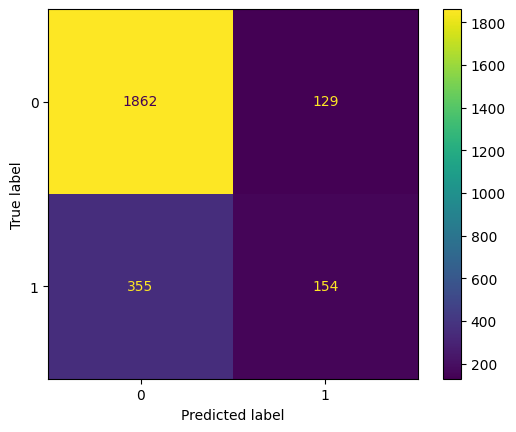

In [15]:
conf_matrix_plot(gnb_scaled, X_test, y_test)

The confusion matrix model misses a lot of customers who will churn. In other words, there are a lot of false negatives 355, to be exact. This is why our recall score is only 0.303. 
